In [ ]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.express as ex
pio.renderers.defalut = 'notebook'
from scipy import stats


: 

In [ ]:
def fronebius(A):
    A = np.sum(A.T ** 2)
    return np.sqrt(A)


rand = np.random.randn(1000).reshape(10, 10, 10)
scalars = np.random.uniform(0, 50, 40)

norms = np.zeros((40,))

for i, scal in enumerate(scalars):
    res = scalars[i] * rand
    res = fronebius(res)
    norms[i] = res

fig = go.Figure(data=[
    go.Scatter(x=scalars, y=norms)
])

fig.show()
scalars

array([21.35026744, 47.14860034, 33.81515121, 21.36074449, 13.35713586,
       10.41476584, 13.14023968, 33.27261439, 12.20663554, 27.49189848,
        6.98496639, 33.45784195, 23.15408526, 29.14160561, 43.63819496,
       12.24819761, 31.03454954, 39.48373447, 39.1551051 , 38.00811458,
       24.76802536, 46.74585195, 14.99467362, 15.51620353, 13.23068971,
       32.44814638, 15.72658277, 18.75383822, 11.65277665, 30.94576709,
       37.96986751, 14.35144916, 29.02832279, 15.82997372, 23.62617493,
       16.25766635, 41.70761724,  4.21883988, 46.602601  , 39.54419674])

In [3]:
def double_fronebius(A1, A2):
    return np.sqrt(np.sum((A1-A2)**2))

s = 1

A1 = np.array([1, 2, 3, 4]).reshape(2, 2)
A2 = np.array([2, 4, 1, 6]).reshape(2, 2)

while double_fronebius(A1, A2) > 1:
    A1 = s * A1
    A2 = s * A2
    s *= 0.9
print(A1)
print(A2) 

[[0.20589113 0.41178226]
 [0.6176734  0.82356453]]
[[0.41178226 0.82356453]
 [0.20589113 1.23534679]]


In [156]:
A1 = np.array([1, 2, 3, 4]).reshape(2, 2)

a = np.diag(A1.T @ A1)
print(np.sqrt(np.sum(a)))
print(fronebius(A1))

5.477225575051661
5.477225575051661


In [4]:
def pirson_corr(A1, A2):
    res = np.sum((A1 - A1.mean()) * (A2 - A2.mean())) / (np.sqrt(np.var(A1)) * np.sqrt(np.var(A2)))
    return res

A = np.random.randn(100).reshape(10, 10)
parts = np.linspace(0, 1, 30)
A_fron = fronebius(A)

norm_x = np.zeros(len(parts))
distance_x = np.zeros(len(parts))
corr_x = np.zeros(len(parts))

for i, num in enumerate(range(len(parts))):
    f = np.diag((A_fron * parts[i])  * np.ones((len(A), )))
    B = A + f
    norm_x[i] = max(np.linalg.norm(A), np.linalg.norm(B)) / min(np.linalg.norm(A), np.linalg.norm(B)) - 1
    distance_x[i] = double_fronebius(A, B)
    corr_x[i] = pirson_corr(A, B)

fig = make_subplots(rows=1, cols=3)
fig.add_trace(go.Scatter(x=norm_x, y = parts), row=1, col=1)
fig.add_trace(go.Scatter(x=distance_x, y = parts), row=1, col=2)
fig.add_trace(go.Scatter(x=corr_x, y = parts), row=1, col=3)

fig.show()


In [226]:
# Cлучайные матрицы с произвольным рангом

def rand_rr_matrix(M, N, r):
    A1 = np.random.randn(M, r)
    A2 = np.random.randn(r, N)
    return A1 @ A2

np.linalg.matrix_rank(rand_rr_matrix(8, 6, 10))

np.int64(6)

In [ ]:
# правило ранга сложения матриц

A1 = rand_rr_matrix(5, 5, 1)
A2 = rand_rr_matrix(5, 5, 1)
A3 = rand_rr_matrix(5, 5, 1)

print(np.linalg.matrix_rank(A1 + rand_rr_matrix(5, 5, 0)))
print(np.linalg.matrix_rank(A1 + rand_rr_matrix(5, 5, 1)))
print(np.linalg.matrix_rank(A1 + rand_rr_matrix(5, 5, 2)))


1
2
3


In [224]:
def rand_r_matrix(M, r):
    A1 = np.random.randn(M, r)
    A2 = np.random.randn(r, M)
    return A1 @ A2

res_sum = np.zeros((14, 14))
res_mult = np.zeros((14, 14))
for i in range(2, 16):
    for j in range(2, 16):
        A1 = rand_r_matrix(20, i)
        A2 = rand_r_matrix(20, j)
        res_sum[i-2, j-2] = np.linalg.matrix_rank(A1 + A2)
        res_mult[i-2, j-2] = np.linalg.matrix_rank(A1 @ A2)


fig1 = ex.imshow(res_sum, 
                        color_continuous_scale='gray',
                        title='Матрица 5×5 (интерактивная)',
                        labels=dict(x='Столбцы', y='Строки', color='Значение'))

fig2 = ex.imshow(res_mult, 
                        color_continuous_scale='gray',
                        title='Матрица 5×5 (интерактивная)',
                        labels=dict(x='Столбцы', y='Строки', color='Значение'))

fig1.show()
fig2.show()

In [225]:
A = rand_r_matrix(5, 3)
print(np.linalg.matrix_rank(A))
print(np.linalg.matrix_rank(A.T))
print(np.linalg.matrix_rank(A @ A.T))
print(np.linalg.matrix_rank(A.T @ A))

3
3
3
3


In [284]:
# Принадлженость вектора столбцовому пространству матрицы

A = rand_rr_matrix(4, 3, 3)
v = np.random.normal(0, 1, 4).reshape(4, 1)
res = np.hstack((A, v))
print(res)
print(np.linalg.matrix_rank(A) == np.linalg.matrix_rank(res))

[[ 0.09086248  1.74424899  0.30877313  1.49455029]
 [-0.79600539  0.11416821  2.99731697  0.7293821 ]
 [-0.31875218 -1.80584764  0.29973917 -0.98293872]
 [ 0.48404621 -1.33305454 -2.99938595  0.17510499]]
False


In [315]:
# Проверка что определитель рангово пониженной матрицы равен нулю

dets_y = np.zeros(28)
log_dets_y = np.zeros(28)
for i in range(3, 31):
    dets = np.zeros(100)
    log_dets = np.zeros(100)
    for j in range(100):
        A = np.random.randn(i, i)
        A[:, 0] =  A[:, 2] * 2
        dets[j] = np.linalg.det(A)
        log_dets[j] = np.log10(np.abs(np.linalg.det(A)+ 1e-300))
    dets_y[i-3] = np.mean(dets)
    log_dets_y[i-3] = np.mean(log_dets)
print(log_dets_y)   
fig = make_subplots(rows=1, cols=2)
x = np.arange(3, 31) ** 2
fig.add_trace(go.Scatter(x=x, y=dets_y), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=log_dets_y), row=1, col=2)


[-214.71106658 -160.78117807 -126.45073957  -89.22847737  -88.95292095
  -91.56875114  -68.3618758   -67.96159558  -61.62575245  -55.54946188
  -40.774846    -43.18618297  -28.20965638  -21.71804095  -21.23329432
  -40.94866439  -23.13251821  -36.9551838   -24.6694609   -24.07545962
  -17.58063032  -25.62548711  -13.23345409   -6.66382273  -11.82218766
   -5.33975347   -4.56609262   -0.82234796]


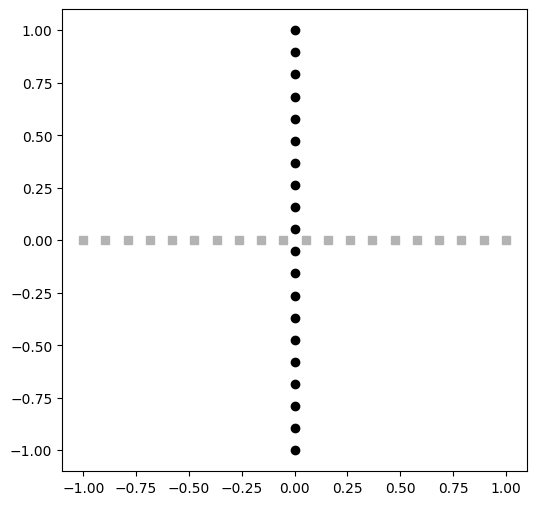

In [12]:
import matplotlib.pyplot as plt

th = np.pi/2

# transformation matrix
T = np.array([
              [ np.cos(th),np.sin(th)],
              [-np.sin(th),np.cos(th)]
            ])

x = np.linspace(-1,1,20)
origPoints = np.vstack( (np.zeros(x.shape),x) )
transformedPoints = T @ origPoints

plt.figure(figsize=(6,6))
plt.plot(origPoints[0, :], origPoints[1, :], 'ko', label='Original')
plt.plot(transformedPoints[0, :], transformedPoints[1, :], 's', color=[.7, .7, .7])



In [ ]:
theta = np.linspace(0, np.pi * 2, 100)
points = np.vstack((np.sin(theta), np.cos(theta)))

fig, ax = plt.subplots(1, figsize=(12, 6))
plth, = ax.plot(np.cos)

array([[ 0.00000000e+00,  6.34239197e-02,  1.26592454e-01,
         1.89251244e-01,  2.51147987e-01,  3.12033446e-01,
         3.71662456e-01,  4.29794912e-01,  4.86196736e-01,
         5.40640817e-01,  5.92907929e-01,  6.42787610e-01,
         6.90079011e-01,  7.34591709e-01,  7.76146464e-01,
         8.14575952e-01,  8.49725430e-01,  8.81453363e-01,
         9.09631995e-01,  9.34147860e-01,  9.54902241e-01,
         9.71811568e-01,  9.84807753e-01,  9.93838464e-01,
         9.98867339e-01,  9.99874128e-01,  9.96854776e-01,
         9.89821442e-01,  9.78802446e-01,  9.63842159e-01,
         9.45000819e-01,  9.22354294e-01,  8.95993774e-01,
         8.66025404e-01,  8.32569855e-01,  7.95761841e-01,
         7.55749574e-01,  7.12694171e-01,  6.66769001e-01,
         6.18158986e-01,  5.67059864e-01,  5.13677392e-01,
         4.58226522e-01,  4.00930535e-01,  3.42020143e-01,
         2.81732557e-01,  2.20310533e-01,  1.58001396e-01,
         9.50560433e-02,  3.17279335e-02, -3.17279335e-0

In [ ]:
y, x = np.meshgrid(np.linspace(-3, 3, 21), np.linspace(-3, 3, 21))
kernel = np.exp(-(x**2 + y**2) / 20)
kernel /= np.sum(kernel)
kernel

array([[0.00125579, 0.00136789, 0.00147664, 0.00157975, 0.00167492,
        0.00175992, 0.00183266, 0.00189131, 0.00193434, 0.00196063,
        0.00196948, 0.00196063, 0.00193434, 0.00189131, 0.00183266,
        0.00175992, 0.00167492, 0.00157975, 0.00147664, 0.00136789,
        0.00125579],
       [0.00136789, 0.00148999, 0.00160844, 0.00172076, 0.00182443,
        0.00191701, 0.00199624, 0.00206013, 0.002107  , 0.00213564,
        0.00214527, 0.00213564, 0.002107  , 0.00206013, 0.00199624,
        0.00191701, 0.00182443, 0.00172076, 0.00160844, 0.00148999,
        0.00136789],
       [0.00147664, 0.00160844, 0.00173632, 0.00185757, 0.00196948,
        0.00206942, 0.00215495, 0.00222391, 0.00227452, 0.00230543,
        0.00231583, 0.00230543, 0.00227452, 0.00222391, 0.00215495,
        0.00206942, 0.00196948, 0.00185757, 0.00173632, 0.00160844,
        0.00147664],
       [0.00157975, 0.00172076, 0.00185757, 0.00198728, 0.002107  ,
        0.00221393, 0.00230543, 0.00237921, 0.0024333